# Data Science Project 1 — Advanced EDA & Feature Engineering

**Goal:** Transform the raw e-commerce dataset into a clean, analysis-ready dataset suitable for machine learning.

### Project requirements
1. Handle missing data using an appropriate statistical/logical imputation method.
2. Detect and treat outliers using **IQR** and **Z-score** analysis.
3. Engineer **at least 3 new predictive features**.
4. Perform exploratory data analysis and visualizations.
5. Validate and export the cleaned dataset.

> **Dataset:** `Dataset for Data Analytics - Sheet1.csv`


## 1. Import Libraries

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [2]:
# 2. Load Dataset

url = "https://raw.githubusercontent.com/rsf-rawnak/DecodeLabs-DS-Internship/main/Initial-dataset/Dataset%20for%20Data%20Analytics%20-%20Sheet1.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!
Rows: 1200
Columns: 14


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 3. Initial Dataset Inspection

In [3]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()


First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



Last 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32



Dataset shape:
(1200, 14)

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode     

## 4. Check Duplicate Records

In [4]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().copy()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 0
No duplicate rows found.


## 5. Missing Value Analysis

In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary.sort_values("Missing Values", ascending=False))


,Missing Values,Missing Percentage
CouponCode,309,25.75


### Missing-value treatment

`CouponCode` is a categorical field. A missing coupon code can reasonably represent an order where no coupon was used, so missing values are replaced with **`No Coupon`** rather than using numerical mean/median imputation.

For other categorical columns, if missing values exist, the mode is used. For numerical columns, the median is used because it is more robust to extreme values than the mean.


In [6]:
# Make a copy before cleaning
df_clean = df.copy()

# Treat missing CouponCode values as "No Coupon"
if "CouponCode" in df_clean.columns:
    df_clean["CouponCode"] = df_clean["CouponCode"].fillna("No Coupon")

# Numerical columns: median imputation
numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns: mode imputation
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_value = df_clean[col].mode(dropna=True)
        if not mode_value.empty:
            df_clean[col] = df_clean[col].fillna(mode_value.iloc[0])

print("Missing-value treatment completed.")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")


Missing-value treatment completed.
Remaining missing values: 0


## 6. Convert Date Column

In [7]:
if "Date" in df_clean.columns:
    df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

    print("Date column converted to datetime.")
    print(f"Invalid/missing dates after conversion: {df_clean['Date'].isna().sum()}")
else:
    print("Date column not found.")


Date column converted to datetime.
Invalid/missing dates after conversion: 0


## 7. Descriptive Statistics

In [8]:
display(df_clean.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,1200,1200,ORD201183,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,NaN,NaN,NaN,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
CustomerID,1200,1189,C46651,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.00,NaN,NaN,NaN,2.95,1.00,2.00,3.00,4.00,5.00,1.41
UnitPrice,1200.00,NaN,NaN,NaN,356.41,11.39,186.06,364.21,521.57,699.93,197.18
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK83653396,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Exploratory Data Analysis (EDA)

In [9]:
# Categorical distributions
categorical_to_check = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "ReferralSource"
]

for col in categorical_to_check:
    if col in df_clean.columns:
        print(f"\n--- {col} ---")
        display(df_clean[col].value_counts(dropna=False))



--- Product ---


,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156



--- PaymentMethod ---


,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230



--- OrderStatus ---


,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231



--- ReferralSource ---


,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


### Numerical distributions

In [10]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

display(df_clean[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Quantity,1200.00,2.95,1.41,1.00,2.00,3.00,4.00,5.00
UnitPrice,1200.00,356.41,197.18,11.39,186.06,364.21,521.57,699.93
ItemsInCart,1200.00,5.49,2.28,1.00,4.00,5.00,7.00,10.00
TotalPrice,1200.00,1053.97,819.86,11.39,410.52,823.62,1578.47,3456.40


### Visualize numerical distributions

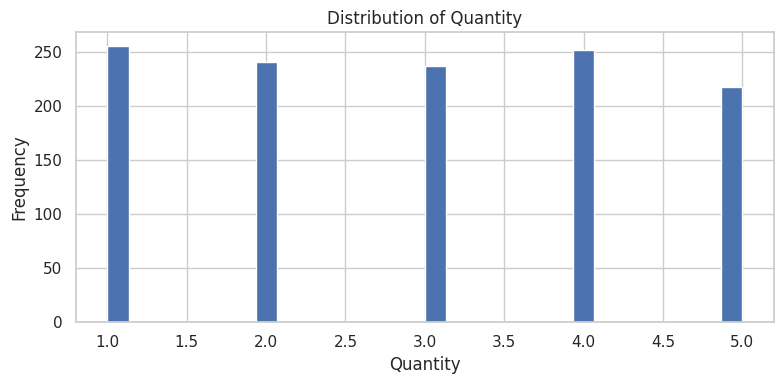

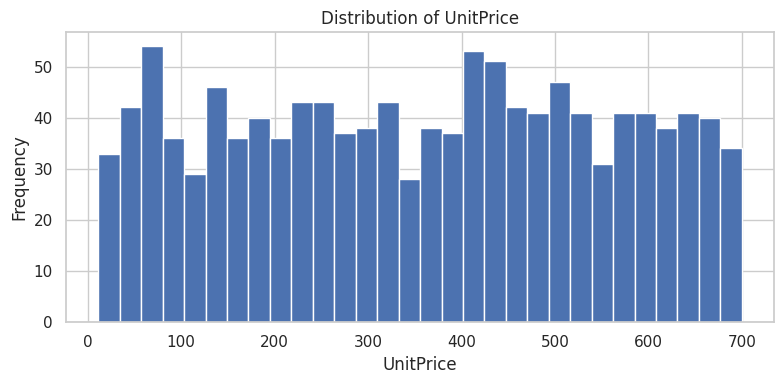

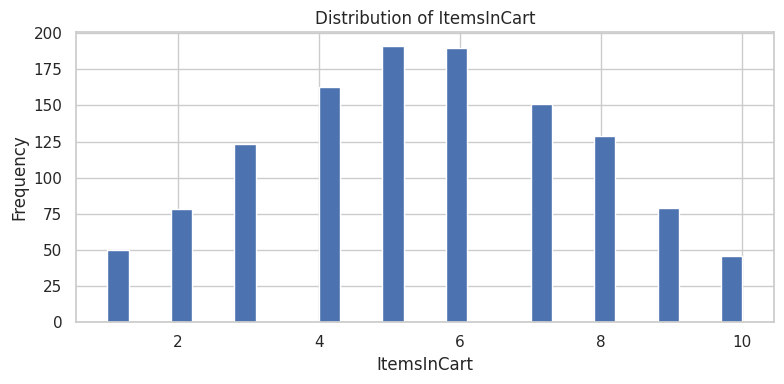

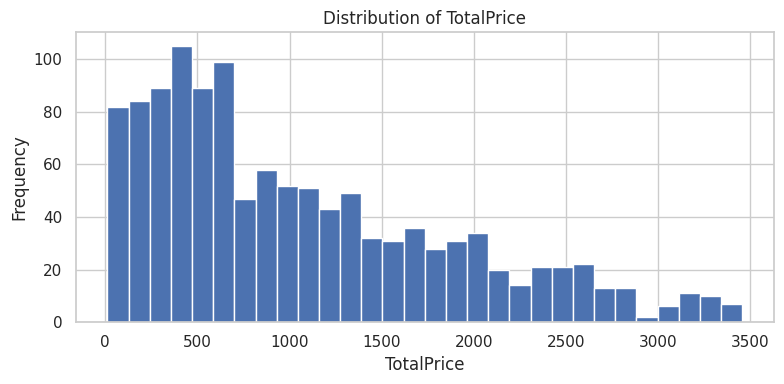

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df_clean[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


### Visualize important categorical variables

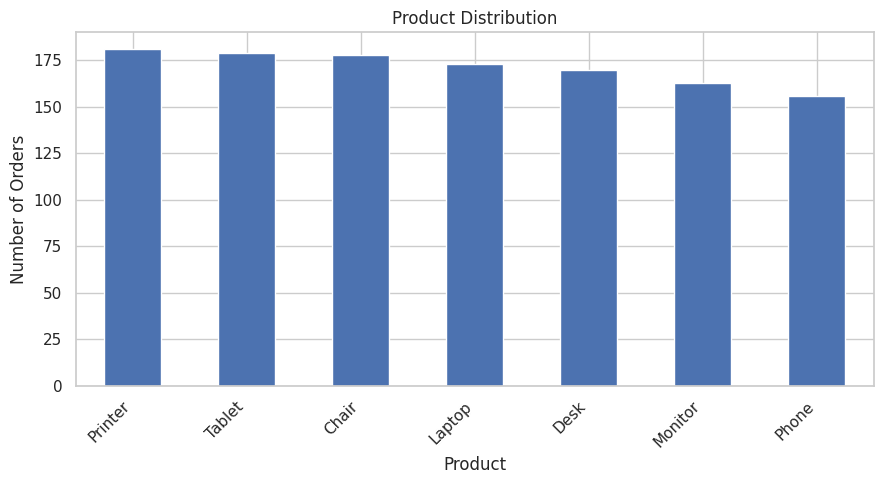

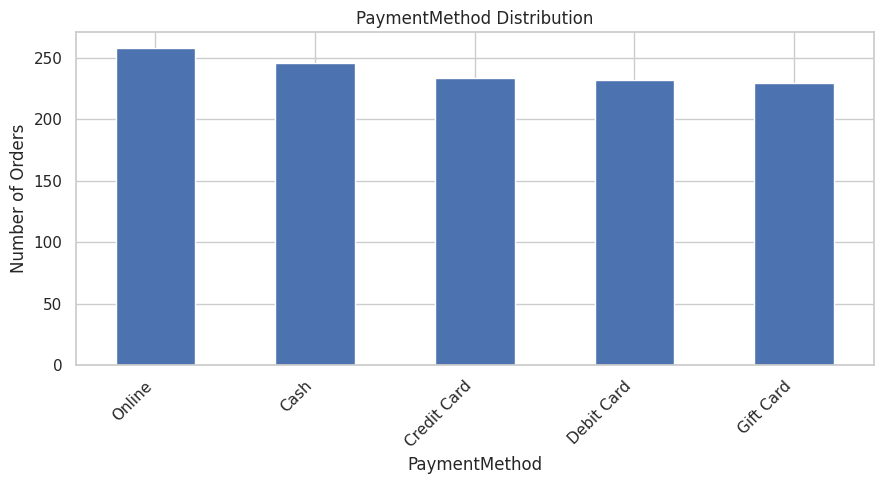

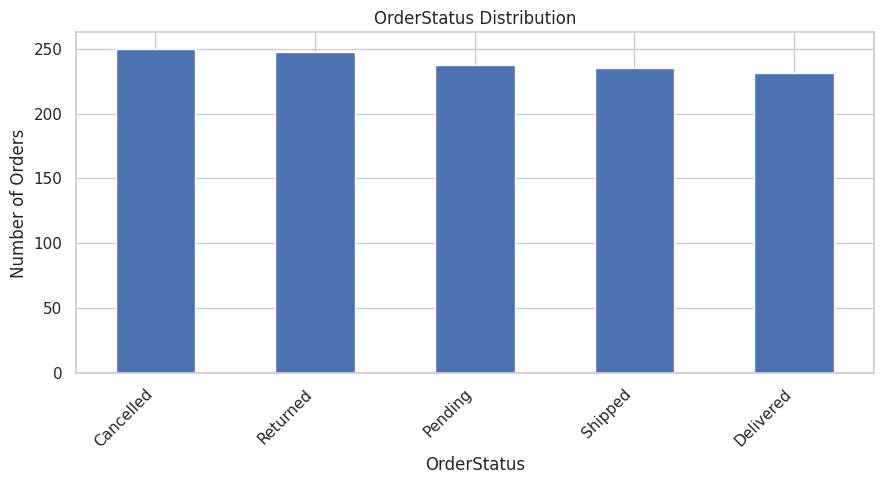

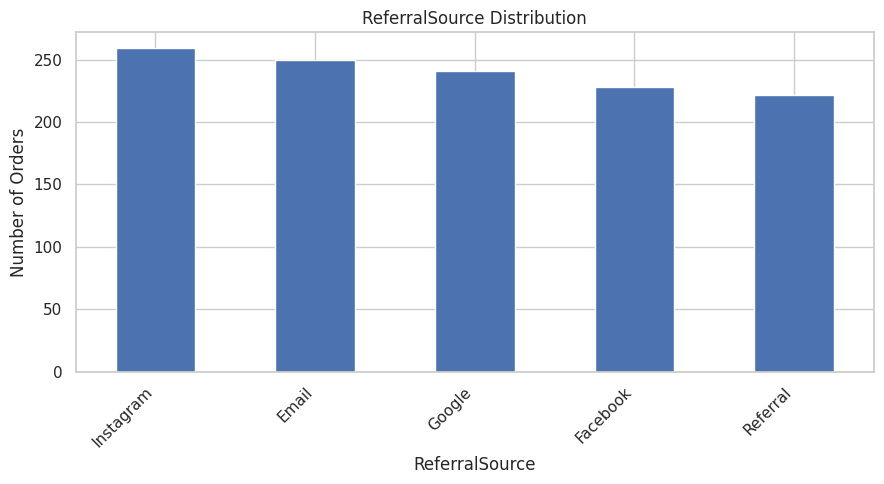

In [12]:
for col in ["Product", "PaymentMethod", "OrderStatus", "ReferralSource"]:
    if col in df_clean.columns:
        plt.figure(figsize=(9, 5))
        df_clean[col].value_counts().plot(kind="bar")
        plt.title(f"{col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Number of Orders")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


## 9. Correlation Analysis

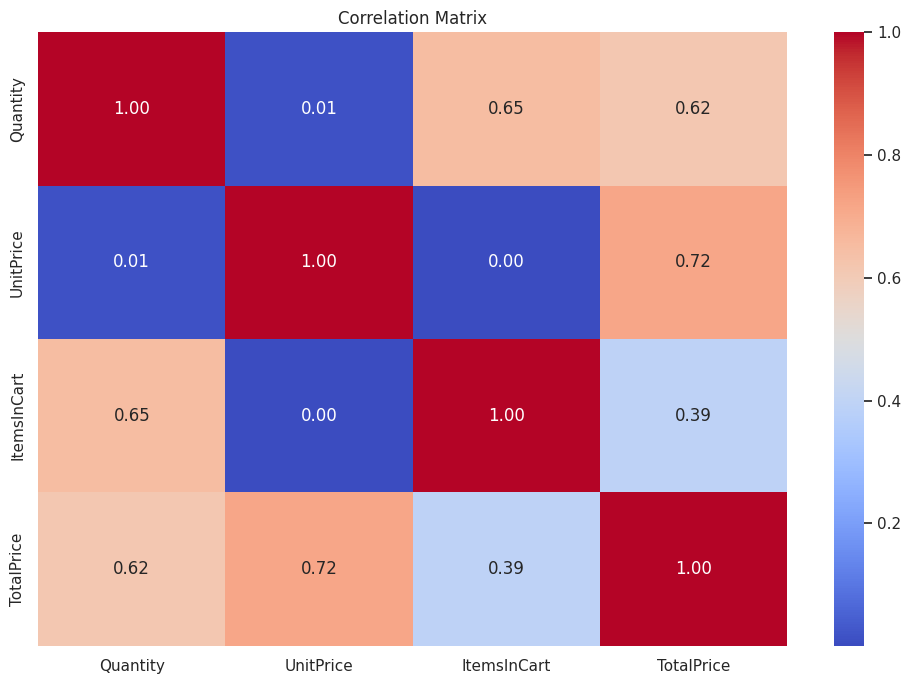

In [13]:
numeric_for_corr = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 10. Outlier Detection — IQR Method

The **Interquartile Range (IQR)** method identifies observations below:

`Q1 - 1.5 × IQR`

or above:

`Q3 + 1.5 × IQR`

We will inspect important numerical variables such as `Quantity`, `UnitPrice`, `ItemsInCart`, and `TotalPrice`.


In [14]:
outlier_summary = []

outlier_columns = [
    col for col in ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
    if col in df_clean.columns
]

for col in outlier_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(outlier_mask.sum()),
        "Outlier Percentage": round(outlier_mask.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Quantity,2.00,4.00,2.00,-1.00,7.00,0,0.00
1,UnitPrice,186.06,521.57,335.51,-317.20,1024.83,0,0.00
2,ItemsInCart,4.00,7.00,3.00,-0.50,11.50,0,0.00
3,TotalPrice,410.52,1578.47,1167.95,-1341.41,3330.41,8,0.67


### Visualize possible outliers with boxplots

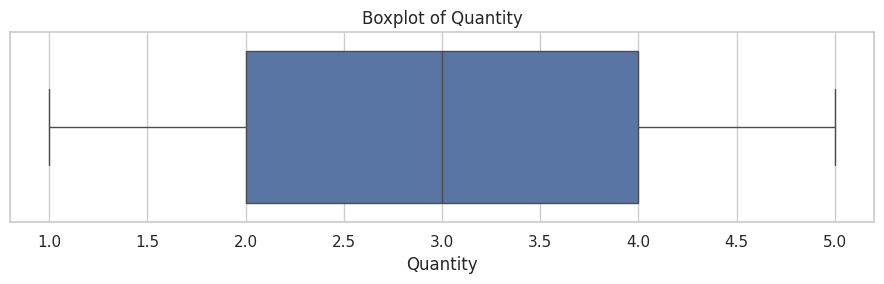

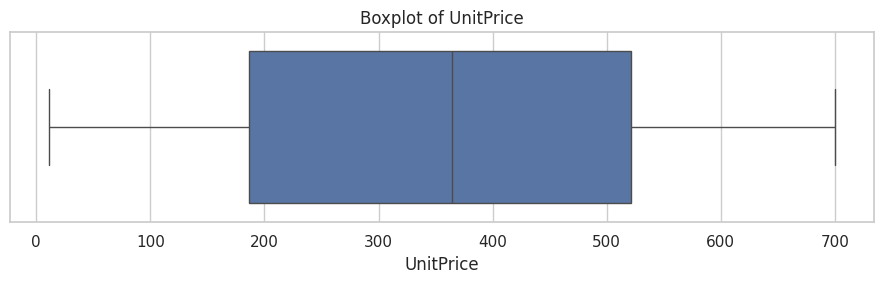

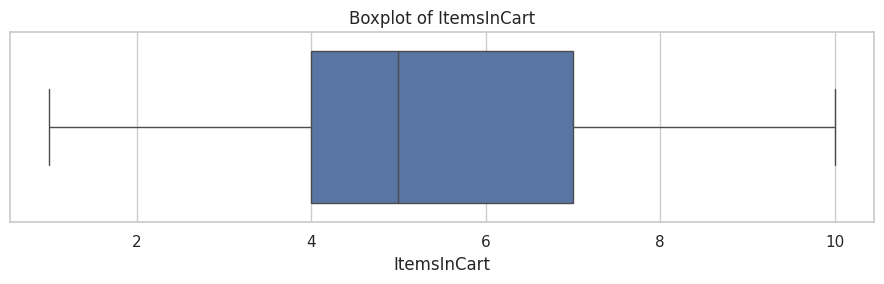

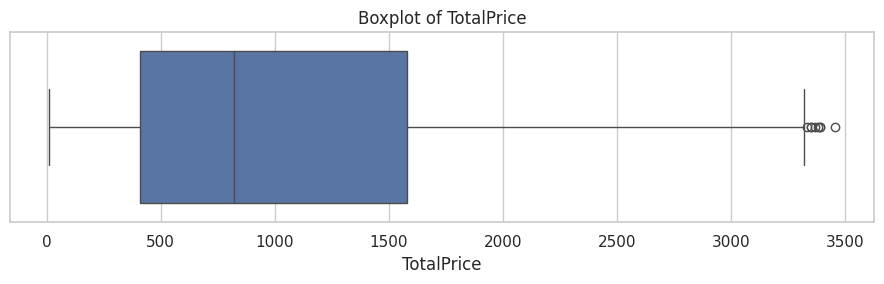

In [15]:
for col in outlier_columns:
    plt.figure(figsize=(9, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


## 11. Outlier Treatment

Outliers should **not automatically be deleted**. A large order can be a legitimate order.

For this project, we use **IQR-based capping (winsorization)** for the selected numerical variables. This keeps the rows while limiting the influence of extreme values.

The original values are preserved in the raw dataset, while `df_clean` becomes the analysis-ready version.


In [16]:
df_before_outlier_treatment = df_clean.copy()

outlier_treatment_log = []

for col in outlier_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before_outliers = ((df_clean[col] < lower_bound) |
                       (df_clean[col] > upper_bound)).sum()

    df_clean[col] = df_clean[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    after_outliers = ((df_clean[col] < lower_bound) |
                      (df_clean[col] > upper_bound)).sum()

    outlier_treatment_log.append({
        "Column": col,
        "Outliers Before": int(before_outliers),
        "Outliers After Capping": int(after_outliers),
        "Lower Cap": lower_bound,
        "Upper Cap": upper_bound
    })

outlier_treatment_log = pd.DataFrame(outlier_treatment_log)
display(outlier_treatment_log)


,Column,Outliers Before,Outliers After Capping,Lower Cap,Upper Cap
0,Quantity,0,0,-1.00,7.00
1,UnitPrice,0,0,-317.20,1024.83
2,ItemsInCart,0,0,-0.50,11.50
3,TotalPrice,8,0,-1341.41,3330.41


## 12. Z-Score Analysis

The project also allows outlier identification through Z-scores.

A common rule is to investigate observations with:

`|Z-score| > 3`

This section is used as an additional statistical check rather than automatically deleting those rows.


In [17]:
zscore_summary = []

for col in outlier_columns:
    z_scores = zscore(df_clean[col].astype(float), nan_policy="omit")
    count = np.sum(np.abs(z_scores) > 3)

    zscore_summary.append({
        "Column": col,
        "Z-score > |3| Count": int(count),
        "Percentage": round((count / len(df_clean)) * 100, 2)
    })

zscore_summary = pd.DataFrame(zscore_summary)
display(zscore_summary)


,Column,Z-score > |3| Count,Percentage
0,Quantity,0,0.00
1,UnitPrice,0,0.00
2,ItemsInCart,0,0.00
3,TotalPrice,0,0.00


## 13. Feature Engineering

We create more useful variables from existing columns.

### Engineered features
1. **PricePerItem** — average price per item in an order.
2. **UsedCoupon** — binary indicator showing whether a coupon was used.
3. **OrderMonth** — month in which the order was placed.
4. **OrderYear** — year in which the order was placed.
5. **CalculatedTotal** — `Quantity × UnitPrice`, useful for consistency checking.

These features are derived from information already present in the dataset.


In [18]:
# Feature 1: Price per item
if {"TotalPrice", "Quantity"}.issubset(df_clean.columns):
    df_clean["PricePerItem"] = (
        df_clean["TotalPrice"] / df_clean["Quantity"].replace(0, np.nan)
    )
    df_clean["PricePerItem"] = df_clean["PricePerItem"].fillna(
        df_clean["PricePerItem"].median()
    )

# Feature 2: Coupon usage indicator
if "CouponCode" in df_clean.columns:
    df_clean["UsedCoupon"] = (
        df_clean["CouponCode"].ne("No Coupon")
    ).astype(int)

# Feature 3: Order month
if "Date" in df_clean.columns:
    df_clean["OrderMonth"] = df_clean["Date"].dt.month

# Feature 4: Order year
if "Date" in df_clean.columns:
    df_clean["OrderYear"] = df_clean["Date"].dt.year

# Feature 5: Calculated total
if {"Quantity", "UnitPrice"}.issubset(df_clean.columns):
    df_clean["CalculatedTotal"] = (
        df_clean["Quantity"] * df_clean["UnitPrice"]
    )

new_features = [
    col for col in [
        "PricePerItem",
        "UsedCoupon",
        "OrderMonth",
        "OrderYear",
        "CalculatedTotal"
    ] if col in df_clean.columns
]

print("New features created:")
print(new_features)


New features created:
['PricePerItem', 'UsedCoupon', 'OrderMonth', 'OrderYear', 'CalculatedTotal']


## 14. Validate the Engineered Features

In [19]:
display(df_clean[new_features].head(10))

print("\nData types of engineered features:")
display(df_clean[new_features].dtypes)


,PricePerItem,UsedCoupon,OrderMonth,OrderYear,CalculatedTotal
0,570.62,1,1,2023,2853.10
1,151.35,1,8,2024,302.70
2,550.68,1,2,2024,2753.40
3,273.19,1,10,2023,273.19
4,626.01,1,5,2025,2504.04
5,245.86,1,10,2023,491.72
6,664.42,1,6,2025,664.42
7,149.55,1,5,2023,747.75
8,134.28,0,4,2025,268.56
9,509.38,1,11,2023,2037.52



Data types of engineered features:


,0
PricePerItem,float64
UsedCoupon,int64
OrderMonth,int32
OrderYear,int32
CalculatedTotal,float64


### Consistency check

`CalculatedTotal` is derived from `Quantity × UnitPrice`.

We compare it with the existing `TotalPrice` column. If the values differ, that does not automatically mean the dataset is wrong — the difference could represent discounts, taxes, shipping, or other business rules not documented in the dataset.


In [20]:
if {"CalculatedTotal", "TotalPrice"}.issubset(df_clean.columns):
    df_clean["TotalPriceDifference"] = (
        df_clean["TotalPrice"] - df_clean["CalculatedTotal"]
    )

    display(
        df_clean[
            ["TotalPrice", "CalculatedTotal", "TotalPriceDifference"]
        ].head(10)
    )

    print("Mean difference:",
          df_clean["TotalPriceDifference"].mean())

    print("Median difference:",
          df_clean["TotalPriceDifference"].median())


,TotalPrice,CalculatedTotal,TotalPriceDifference
0,2853.10,2853.10,0.00
1,302.70,302.70,0.00
2,2753.40,2753.40,0.00
3,273.19,273.19,0.00
4,2504.04,2504.04,0.00
5,491.72,491.72,0.00
6,664.42,664.42,0.00
7,747.75,747.75,0.00
8,268.56,268.56,0.00
9,2037.52,2037.52,0.00


Mean difference: -0.32511666666666544
Median difference: 0.0


## 14b. Post-Engineering Collinearity Check

The correlation heatmap in Section 9 ran *before* feature engineering, so it never
evaluated whether the new features (`PricePerItem`, `CalculatedTotal`, etc.) duplicate
signal already present in the dataset. Re-checking now, on the full feature set,
using the same 0.80 threshold referenced in the project brief.


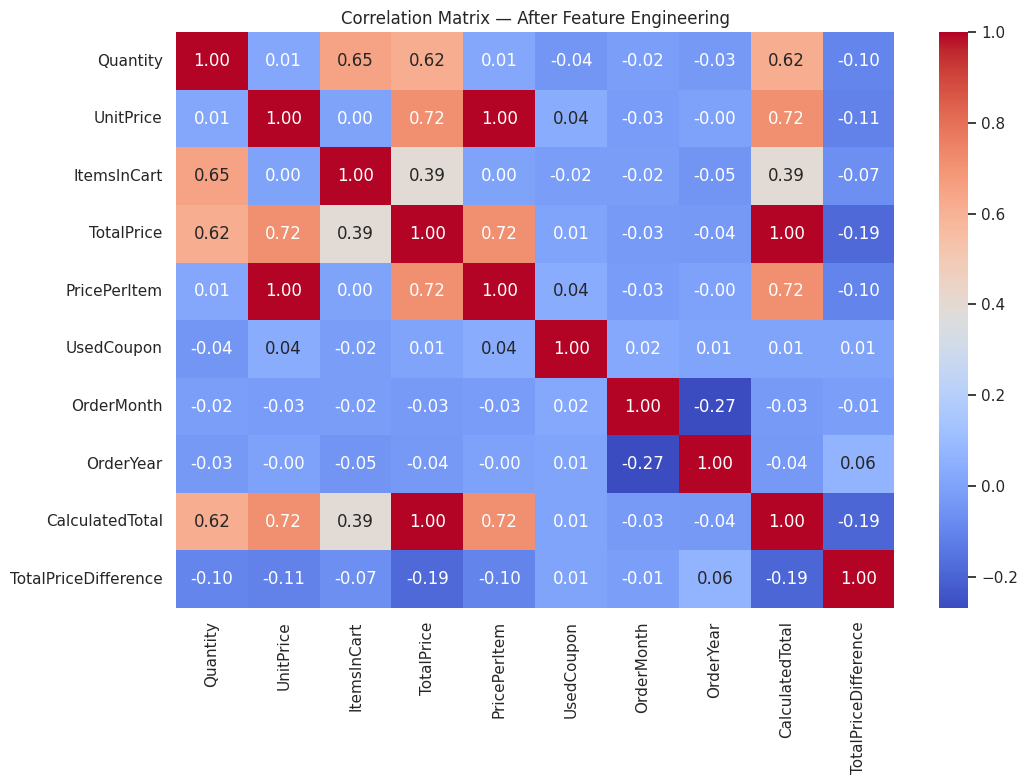

Highly correlated pairs (>0.80) — review for redundancy:
  UnitPrice <-> PricePerItem: 1.000
  TotalPrice <-> CalculatedTotal: 1.000


In [21]:
post_fe_numeric = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(11, 8))
sns.heatmap(post_fe_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — After Feature Engineering")
plt.tight_layout()
plt.show()

# Flag any pair above 0.80 (same threshold the project brief uses)
corr_matrix = post_fe_numeric.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80
]

if high_corr_pairs:
    print("Highly correlated pairs (>0.80) — review for redundancy:")
    for col, row, val in high_corr_pairs:
        print(f"  {row} <-> {col}: {val:.3f}")
else:
    print("No feature pairs exceed the 0.80 correlation threshold.")


## 15. Final Data Quality Check

In [22]:
print("FINAL DATA QUALITY REPORT")
print("=" * 50)

print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")

print("\nMissing values by column:")
display(df_clean.isnull().sum())

print("\nFinal column list:")
for i, col in enumerate(df_clean.columns, start=1):
    print(f"{i}. {col}")


FINAL DATA QUALITY REPORT
Rows: 1200
Columns: 20
Duplicate rows: 0
Total missing values: 0

Missing values by column:


,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0



Final column list:
1. OrderID
2. Date
3. CustomerID
4. Product
5. Quantity
6. UnitPrice
7. ShippingAddress
8. PaymentMethod
9. OrderStatus
10. TrackingNumber
11. ItemsInCart
12. CouponCode
13. ReferralSource
14. TotalPrice
15. PricePerItem
16. UsedCoupon
17. OrderMonth
18. OrderYear
19. CalculatedTotal
20. TotalPriceDifference


## 16. Final Numerical Summary

In [23]:
display(df_clean.describe().T)


,count,mean,min,25%,50%,75%,max,std
Date,1200,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
Quantity,1200.00,2.95,1.00,2.00,3.00,4.00,5.00,1.41
UnitPrice,1200.00,356.41,11.39,186.06,364.21,521.57,699.93,197.18
ItemsInCart,1200.00,5.49,1.00,4.00,5.00,7.00,10.00,2.28
TotalPrice,1200.00,1053.64,11.39,410.52,823.62,1578.47,3330.41,818.94
PricePerItem,1200.00,356.35,11.39,186.06,364.21,521.57,699.93,197.07
UsedCoupon,1200.00,0.74,0.00,0.00,1.00,1.00,1.00,0.44
OrderMonth,1200.00,6.00,1.00,3.00,6.00,9.00,12.00,3.34
OrderYear,1200.00,2023.77,2023.00,2023.00,2024.00,2024.00,2025.00,0.75
CalculatedTotal,1200.00,1053.97,11.39,410.52,823.62,1578.47,3456.40,819.86


## 17. Save the Cleaned Dataset

In [24]:
output_file = "cleaned_dataset_project1.csv"

df_clean.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")


Cleaned dataset saved as: cleaned_dataset_project1.csv


## 18. Final Project Summary

### Work completed
- Loaded the raw e-commerce dataset.
- Inspected rows, columns, data types, and duplicates.
- Identified missing values.
- Applied appropriate missing-value treatment.
- Performed exploratory data analysis.
- Visualized numerical and categorical variables.
- Detected potential outliers using the IQR method.
- Used IQR-based capping to reduce the influence of extreme values.
- Performed an additional Z-score outlier check.
- Engineered at least 3 new features:
  - `PricePerItem`
  - `UsedCoupon`
  - `OrderMonth`
  - plus `OrderYear` and `CalculatedTotal`
- Validated the final dataset.
- Exported the cleaned dataset as `cleaned_dataset_project1.csv`.

### Final objective

The resulting dataset is cleaner and contains additional derived features that can be used for further data analysis or machine-learning work.
